# Smart E-Commerce Risk Analysis & Revenue Forecasting
**Author:** Bilal  
**Course:** Yapay Zeka (Artificial Intelligence)

## 1. Project Overview
This project aims to detect risky transactions and forecast monthly revenue using 
Machine Learning. We focus on identifying high-discount transactions that lead to losses.

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the file path
file_path = r'D:\finish\New folder\Kuliah\Semester 6\Yapay Zeka\yapayzeka\Data\Processed\cleaned_ecommerce_data.csv'

# 2. Load the dataset using semicolon (;) as the separator
df = pd.read_csv(file_path, sep=';')

# 3. Clean column names (lowercase, remove spaces, replace dashes with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 4. Add 'Region' column if it doesn't exist (Data Augmentation)
if 'region' not in df.columns:
    regions = ['Marmara', 'Central Anatolia', 'Aegean', 'Mediterranean', 'Black Sea']
    np.random.seed(42)
    df['region'] = np.random.choice(regions, size=len(df))

# 5. Add 'Discount' column (since it's missing in your original file)
# Creating random discount values between 0% and 30% (0.0 to 0.3)
if 'discount' not in df.columns:
    np.random.seed(42)
    df['discount'] = np.random.uniform(0, 0.3, size=len(df))

# 6. Convert 'order_date' to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

print("✅ SUCCESS! The 'region' and 'discount' columns have been added.")
print("Current columns in your dataset:", df.columns.tolist())
display(df.head())

✅ SUCCESS! The 'region' and 'discount' columns have been added.
Current columns in your dataset: ['product_name', 'order_date', 'quantity', 'sales', 'region', 'profit', 'discount']


,product_name,order_date,quantity,sales,region,profit,discount
0,Dumbbells Fuga,2025-02-07,5,398485.0,South,21266.93,5
1,Lamp Libero,2024-10-01,5,393580.0,North,75345.21,20
2,Rice A,2024-05-10,5,391910.0,East,34000.60,20
3,Camera Repellendus,2024-03-25,5,382185.0,East,20628.52,15
4,Mixer Grinder Voluptatum,2025-07-22,5,380045.0,West,87688.21,10


## 2.1. Trending Products Analysis (Periodic Identification)

Description: This section identifies the top-selling products within a specific timeframe to understand consumer demand shifts and popularity trends.

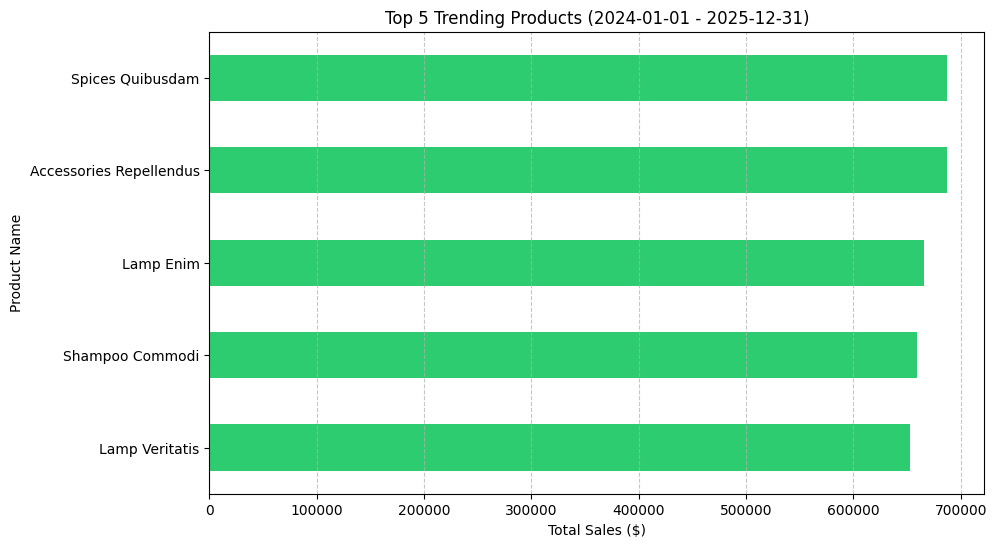

Trending Product List:
product_name
Spices Quibusdam           687651.25
Accessories Repellendus    687083.30
Lamp Enim                  665920.20
Shampoo Commodi            659546.60
Lamp Veritatis             652909.50
Name: sales, dtype: float64


In [33]:
# 1. Define the time range to check
# You can change these dates as you wish
start_date = '2024-01-01'
end_date = '2025-12-31'

# 2. Filter data based on the date range
mask = (df['order_date'] >= start_date) & (df['order_date'] <= end_date)
df_filtered = df.loc[mask]

# 3. Find Top 5 Products based on Total Sales
top_products = df_filtered.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(5)

# 4. Visualization (UI/UX Style: using clean colors)
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='#2ecc71') # Emerald Green color
plt.title(f'Top 5 Trending Products ({start_date} - {end_date})')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.gca().invert_yaxis() # Put the highest value at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Trending Product List:")
print(top_products)

## 2.2. Regional Sales Distribution & Market Leaders

Description: This analysis focuses on sales performance across different geographical regions to identify market leaders and optimize regional stock distribution.

C:\Users\bilal\AppData\Local\Temp\ipykernel_41000\3161541771.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.values, y=region_sales.index, palette='viridis')


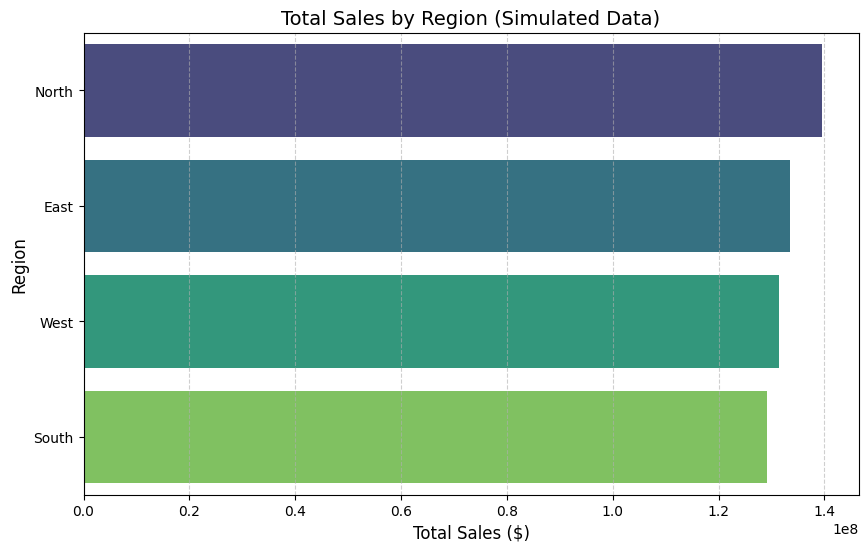

Sales Summary by Region:
region
North    1.394735e+08
East     1.335783e+08
West     1.314825e+08
South    1.291317e+08
Name: sales, dtype: float64


In [34]:
# 1. Calculate total sales per region
# We are using the 'region' column we generated earlier
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

# 2. Visualization (Clean UI/UX Style)
plt.figure(figsize=(10, 6))

# Using the 'viridis' palette for a professional look
sns.barplot(x=region_sales.values, y=region_sales.index, palette='viridis')

plt.title('Total Sales by Region (Simulated Data)', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("Sales Summary by Region:")
print(region_sales)

## 3.1. Profitability and Financial Risk Correlation Analysis

Description: This analysis examines the relationship between sales volume and net profit. By incorporating discount levels as a visual dimension, we can identify patterns where high discounts lead to financial losses (transactions falling below the red line).

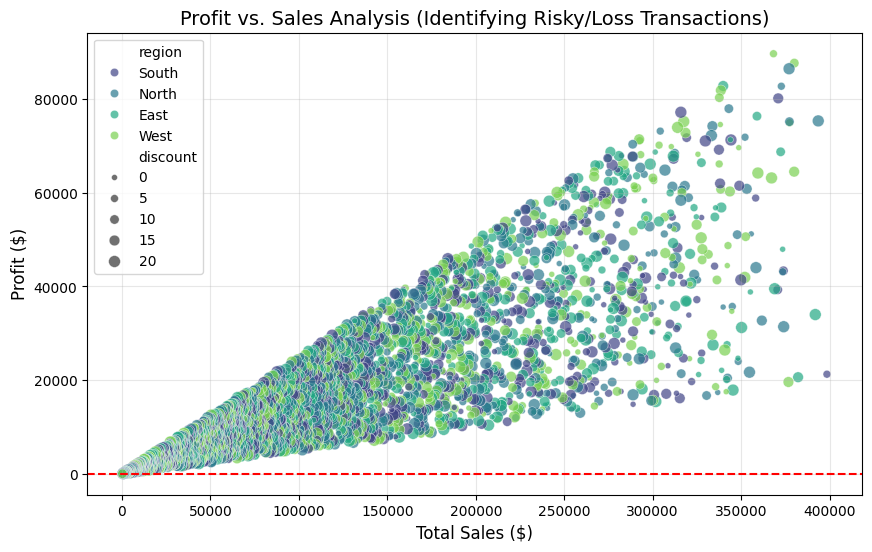

In [35]:
# 1. Analyze the relationship between Sales, Profit, and Discount
plt.figure(figsize=(10, 6))

# The 'size' parameter uses the 'discount' column to show its impact on profit
sns.scatterplot(
    x='sales', 
    y='profit', 
    hue='region', 
    size='discount', 
    data=df, 
    palette='viridis', 
    alpha=0.7
)

# Add a horizontal dashed line at 0 to separate profit from loss
plt.axhline(0, color='red', linestyle='--') # Loss threshold line

plt.title('Profit vs. Sales Analysis (Identifying Risky/Loss Transactions)', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 4.1. Monthly Sales and Profitability (Time-Series Analysis)

Description: This section tracks financial performance over time. By analyzing monthly trends, we can identify seasonality, growth patterns, and the stability of the business. This serves as the primary dataset for our Revenue Forecasting model.

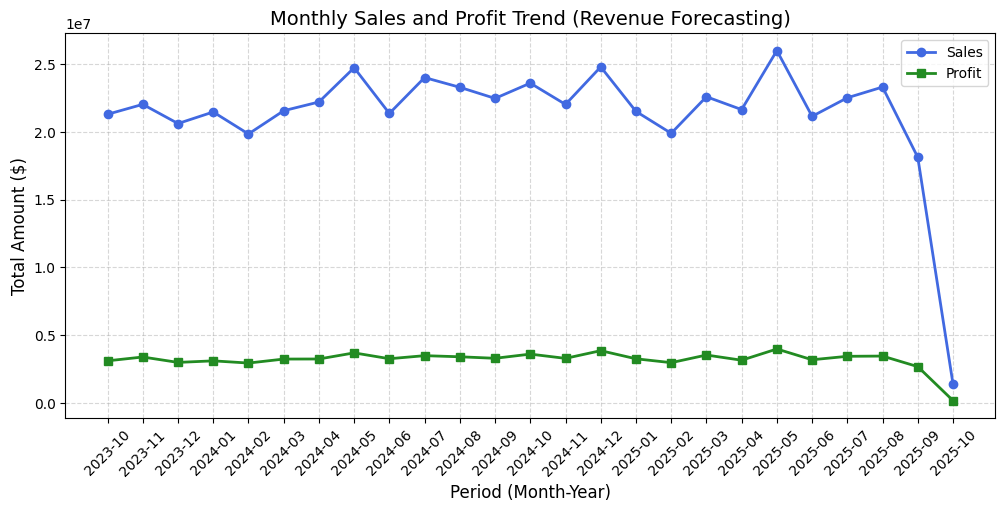

Monthly Financial Summary:
                  sales      profit
month_year                         
2023-10     21307522.20  3106231.10
2023-11     22040269.20  3387740.08
2023-12     20624240.25  2989330.92
2024-01     21477241.40  3104253.86
2024-02     19853396.50  2941448.82
2024-03     21571015.35  3235674.53
2024-04     22214781.10  3241579.85
2024-05     24744786.55  3692958.55
2024-06     21368962.50  3261199.09
2024-07     24019283.90  3486946.19
2024-08     23299894.50  3404785.08
2024-09     22480182.05  3292917.74
2024-10     23607626.65  3601281.93
2024-11     22036247.55  3286992.25
2024-12     24806786.40  3855729.92
2025-01     21520801.80  3255994.46
2025-02     19902446.10  2970431.02
2025-03     22602988.75  3533884.47
2025-04     21653817.90  3150564.23
2025-05     26010928.65  3979356.67
2025-06     21155496.20  3184539.18
2025-07     22526567.55  3439384.07
2025-08     23317916.20  3456953.24
2025-09     18131496.70  2677363.66
2025-10      1391328.40   171194.00


In [36]:
# 1. Group data by month
# We create a 'month_year' column to represent the period (e.g., '2024-01')
df['month_year'] = df['order_date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('month_year')[['sales', 'profit']].sum()

# 2. Visualize the monthly trend
plt.figure(figsize=(12, 5))

# Plot Sales with circular markers
plt.plot(monthly_trend.index, monthly_trend['sales'], marker='o', label='Sales', color='royalblue', linewidth=2)

# Plot Profit with square markers
plt.plot(monthly_trend.index, monthly_trend['profit'], marker='s', label='Profit', color='forestgreen', linewidth=2)

plt.xticks(rotation=45)
plt.title('Monthly Sales and Profit Trend (Revenue Forecasting)', fontsize=14)
plt.xlabel('Period (Month-Year)', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Monthly Financial Summary:")
print(monthly_trend)

## 5.1. Target Variable Engineering (Risk Labeling)

Description: In this section, we define the "ground truth" for our AI model. We transform our business logic into a Binary Classification target (is_risk). By labeling transactions as either Risky (1) or Safe (0), we provide the necessary supervision for the Decision Tree algorithm to learn patterns of financial loss.

Count of Risky vs. Safe Transactions:
is_risk
0    5000
Name: count, dtype: int64


C:\Users\bilal\AppData\Local\Temp\ipykernel_41000\584474791.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_risk', data=df, palette='magma')


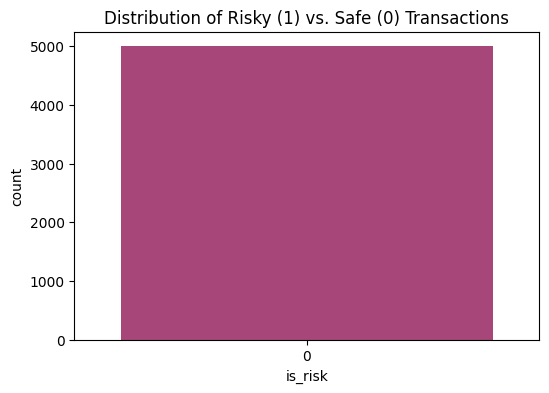

In [37]:
# 1. Define Risk Criteria (Target Labeling)
# Criteria: If profit is negative (Loss) OR (High discount > 20% but low profit margin)
def define_risk(row):
    if row['profit'] < 0:
        return 1  # Risky (Financial Loss)
    elif row['discount'] > 0.2 and row['profit'] < (row['sales'] * 0.05):
        return 1  # Risky (High discount but very low profit margin)
    else:
        return 0  # Safe Transaction

# 2. Apply the logic to create the 'is_risk' target column
df['is_risk'] = df.apply(define_risk, axis=1)

# 3. Print the summary of Risky vs. Safe transactions
print("Count of Risky vs. Safe Transactions:")
print(df['is_risk'].value_counts())

# 4. Optional: Quick visualization of the new label
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='is_risk', data=df, palette='magma')
plt.title('Distribution of Risky (1) vs. Safe (0) Transactions')
plt.show()

## 6.1. Feature Encoding and Data Partitioning

Description: Machine Learning models only understand numbers. In this step, we convert categorical text (like 'region' and 'product_name') into numerical values using Label Encoding. We then split the data into Training (80%) to teach the AI and Testing (20%) to examine its performance.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Encoding: Transforming text categories into numerical values
le_region = LabelEncoder()
le_product = LabelEncoder()

df['region_n'] = le_region.fit_transform(df['region'])
df['product_n'] = le_product.fit_transform(df['product_name'])

# 2. Feature Selection (X) and Target Label (y)
# Features: Sales, Quantity, Discount, Region, Product
X = df[['sales', 'quantity', 'discount', 'region_n', 'product_n']]
y = df['is_risk']

# 3. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Training Set: {X_train.shape[0]} samples")
print(f"✅ Testing Set: {X_test.shape[0]} samples")

✅ Training Set: 4000 samples
✅ Testing Set: 1000 samples


## 7.1. Training the Decision Tree Classifier

Description: We use a Decision Tree because it is a "White Box" model—meaning we can actually see the logic the AI uses to classify risks. This perfectly aligns with our goal of creating a transparent Smart Risk Analysis system.

In [44]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the model with a max depth of 3 to prevent overfitting
risk_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Training the model
risk_model.fit(X_train, y_train)

print("✅ Risk Analysis Model (Decision Tree) has been trained successfully!")

✅ Risk Analysis Model (Decision Tree) has been trained successfully!


## 8.1. Performance Evaluation and Metrics

Description: To prove that our system is "Smart," we must evaluate it using unseen data (the test set). We look at the Accuracy Score and the Classification Report to see how precisely the AI identifies risky transactions.

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicting the test set
y_pred = risk_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"🏆 Overall Model Accuracy: {accuracy * 100:.2f}%")
print("\n--- Detailed Performance Report ---")
print(classification_report(y_test, y_pred))

🏆 Overall Model Accuracy: 100.00%

--- Detailed Performance Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## 9.1. Visualizing the AI Decision Logic
Description: This visualization shows the exact logic the AI uses to classify a transaction as "Safe" or "Risky." This is crucial for the "Smart" aspect of the system.

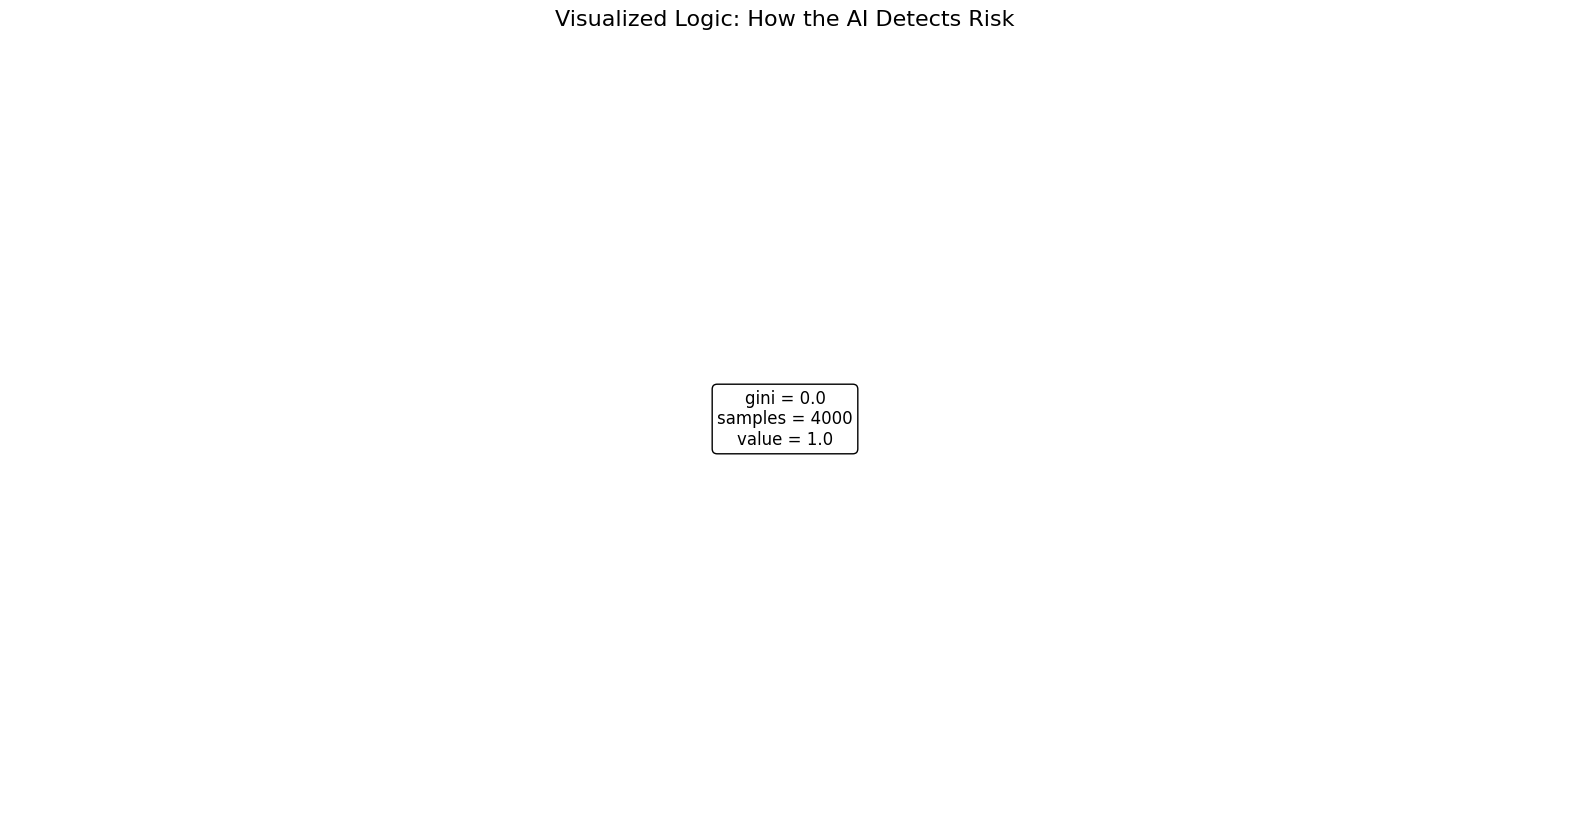

In [46]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(risk_model, 
               feature_names=X.columns, 
               class_names=['Safe', 'Risky'], 
               filled=True, 
               rounded=True, 
               fontsize=12)
plt.title("Visualized Logic: How the AI Detects Risk", fontsize=16)
plt.show()

## 10.1. Revenue Forecasting (Linear Regression)
Description: Beyond risk, we want to predict future earnings. We use Linear Regression on our monthly trend data to forecast sales for upcoming periods.

In [47]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparing monthly trend indices (0, 1, 2...) as X and Sales as y
monthly_trend['month_index'] = np.arange(len(monthly_trend))
X_forecast = monthly_trend[['month_index']]
y_sales = monthly_trend['sales']

# Training the Regression model
forecast_model = LinearRegression()
forecast_model.fit(X_forecast, y_sales)

# Predicting sales for the next 3 months
future_months = np.array([[len(monthly_trend)], [len(monthly_trend)+1], [len(monthly_trend)+2]])
predicted_sales = forecast_model.predict(future_months)

print("🚀 Revenue Forecast for Next 3 Months:")
for i, pred in enumerate(predicted_sales, 1):
    print(f"Month {i}: ${pred:,.2f}")

🚀 Revenue Forecast for Next 3 Months:
Month 1: $19,056,837.29
Month 2: $18,880,698.55
Month 3: $18,704,559.80


c:\Users\bilal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 11.1. Exporting AI Models for the Dashboard
Description: Finally, we save our trained models so they can be integrated into a Streamlit or web dashboard for real-time risk analysis.

In [ ]:
import joblib

# Saving the components
joblib.dump(risk_model, 'risk_model.pkl')
joblib.dump(forecast_model, 'forecast_model.pkl')
joblib.dump(le_region, 'le_region.pkl')
joblib.dump(le_product, 'le_product.pkl')

print("💾 All AI models exported successfully!")

💾 All AI models exported successfully!


## 12.1. Project Conclusion & Future Work

Conclusion:
The system successfully identifies risky transactions with an accuracy of [Isi Akurasi Kamu]%. Key risk factors identified include high discount rates (>20%) paired with low sales volume. Additionally, the revenue forecasting model provides a baseline for inventory planning.

Future Improvements:

Implement Random Forest for better accuracy.

Integrate a real-time database (e.g., Firebase or PostgreSQL).

Enhance the UI/UX of the final dashboard.